# HemaVision - Huấn luyện MobileNetV2 Phân Loại Tế Bào Máu

**Pipeline**: Dữ liệu YOLO → Cân bằng dataset → Phase 1 Transfer Learning → Phase 2 Fine-Tuning

**Kết quả**: `mobilenetv2_phase2_best.h5` — model chính đang được dùng trong hệ thống HemaVision.

## Bước 1: Nạp Dữ Liệu lên SSD Cục Bộ

Đồng bộ dataset đã cân bằng (2000 ảnh/lớp) từ Google Drive sang SSD để tăng tốc I/O.

In [ ]:
import os
import shutil

# 1. Define paths
ZIP_PATH = '/content/drive/MyDrive/blood_cell_project/data/dataset_v2_clean/balanced_train_2000.zip'
LOCAL_EXTRACT_PATH = '/content/dataset/'

# 2. Check source file existence
if os.path.exists(ZIP_PATH):
    print(f'[INFO] Found source archive at: {ZIP_PATH}')

    # 3. Create destination directory if not exists
    if not os.path.exists(LOCAL_EXTRACT_PATH):
        os.makedirs(LOCAL_EXTRACT_PATH)
        print(f'[INFO] Created local directory: {LOCAL_EXTRACT_PATH}')

    # 4. Use shell command to unzip directly to local SSD
    print('⏳ Extracting dataset to local SSD (this is faster for training)...')
    !unzip -q "{ZIP_PATH}" -d "{LOCAL_EXTRACT_PATH}"
    print('✅ Extraction complete.')

    # 5. Verify the structure
    extracted_items = os.listdir(LOCAL_EXTRACT_PATH)
    # Check if nested or direct
    if len(extracted_items) == 1 and os.path.isdir(os.path.join(LOCAL_EXTRACT_PATH, extracted_items[0])):
        # Some zips contain a root folder
        DATA_ROOT = os.path.join(LOCAL_EXTRACT_PATH, extracted_items[0])
    else:
        DATA_ROOT = LOCAL_EXTRACT_PATH

    classes = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])
    print(f'\n[VERIFICATION] Found {len(classes)} class directories in {DATA_ROOT}:')
    print(classes)
else:
    print(f'[ERROR] Could not find {ZIP_PATH}. Please ensure Drive is mounted correctly.')

[INFO] Found source archive at: /content/drive/MyDrive/blood_cell_project/data/dataset_v2_clean/balanced_train_2000.zip
[INFO] Created local directory: /content/dataset/
⏳ Extracting dataset to local SSD (this is faster for training)...
✅ Extraction complete.

[VERIFICATION] Found 14 class directories in /content/dataset/:
['BA', 'BNE', 'EO', 'ERB', 'IG', 'LY', 'MMY', 'MO', 'MY', 'MYO', 'PLT', 'PMY', 'RBC', 'SNE']


## Bước 2: Khởi Tạo Data Pipeline

Tạo `tf.data.Dataset` với rescaling 1/255, shuffle, cache, prefetch.

In [ ]:
import tensorflow as tf
import os

# 1. Cấu hình đường dẫn dữ liệu cục bộ
DATA_DIR = '/content/dataset/'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print(f'[INFO] Đang khởi tạo pipeline dữ liệu từ: {DATA_DIR}')

# 2 & 3. Nạp và chia tập dữ liệu huấn luyện/kiểm định
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# 4. Tối ưu hóa hiệu suất luồng dữ liệu
AUTOTUNE = tf.data.AUTOTUNE

# Tập huấn luyện: Cache -> Shuffle -> Prefetch
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

# Tập kiểm định: Cache -> Prefetch
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 5. Xác nhận danh sách lớp (class_names)
class_names = [d for d in sorted(os.listdir(DATA_DIR)) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f'\n[OK] Tìm thấy {len(class_names)} lớp tế bào máu: {class_names}')
print('[SUCCESS] Pipeline dữ liệu đã được tối ưu hóa và sẵn sàng.')

[INFO] Đang khởi tạo pipeline dữ liệu từ: /content/dataset/
Found 28000 files belonging to 14 classes.
Using 22400 files for training.
Found 28000 files belonging to 14 classes.
Using 5600 files for validation.

[OK] Tìm thấy 14 lớp tế bào máu: ['BA', 'BNE', 'EO', 'ERB', 'IG', 'LY', 'MMY', 'MO', 'MY', 'MYO', 'PLT', 'PMY', 'RBC', 'SNE']
[SUCCESS] Pipeline dữ liệu đã được tối ưu hóa và sẵn sàng.


## Bước 3: Khởi Tạo Kiến Trúc MobileNetV2

- Base: `MobileNetV2` (ImageNet weights, `include_top=False`)
- Head: `GlobalAveragePooling2D` → `Dropout(0.2)` → `Dense(14, softmax)`
- Giai đoạn đầu: **Freeze** toàn bộ base model.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers

# 1. Load the MobileNetV2 base model with pre-trained ImageNet weights
print('[INFO] Loading MobileNetV2 base model...')
base_model = applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the base model to perform feature extraction
base_model.trainable = False

# 3. Construct the Sequential model with a custom classification head
model = models.Sequential([
    # MobileNetV2 expects input in range [-1, 1]
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(14, activation='softmax')
])

# 4. Compile the model
print('[INFO] Compiling model for Phase 1...')
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Display summary to verify parameters
model.summary()
print('\n[SUCCESS] MobileNetV2 architecture initialized and frozen for Phase 1.')

[INFO] Loading MobileNetV2 base model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[INFO] Compiling model for Phase 1...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,275,918 (8.68 MB)

 Trainable params: 17,934 (70.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


[SUCCESS] MobileNetV2 architecture initialized and frozen for Phase 1.


## Bước 4: Huấn Luyện Phase 1 (Transfer Learning)

- Train head với LR = `1e-3` (~10 epochs)
- Unfreeze 20 layer cuối, train với LR = `1e-4` (~5 epochs)
- Lưu model tốt nhất: `mobilenetv2_phase1_best.h5`

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

# ==========================================
# 1. KHỞI TẠO LẠI DATA PIPELINE TỪ Ổ CỤC BỘ
# ==========================================
print("Đang khởi tạo lại Data Pipeline...")
DATA_DIR = '/content/local_dataset/' # <--- ĐÃ SỬA CHUẨN THEO ẢNH CỦA BẠN
IMG_SIZE = (224, 224) # Kích thước chuẩn MobileNetV2
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_ds = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_ds = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

# ==========================================
# 2. NẠP MÔ HÌNH VÀ CẤU HÌNH FINE-TUNING
# ==========================================
# Đảm bảo tên file này khớp với file tốt nhất của Phase 1 trên Drive của bạn
PHASE1_MODEL_PATH = '/content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase1_best.h5'
SAVE_PHASE2_DIR = '/content/drive/MyDrive/blood_cell_project/models/'

print("\nĐang nạp mô hình Phase 1 từ Drive...")
model = load_model(PHASE1_MODEL_PATH)
print("✅ Đã nạp thành công mô hình Phase 1!")

print("Đang rã đông (Unfreeze) toàn bộ các lớp của MobileNetV2...")
model.trainable = True

print("Đang Compile mô hình với Adam(1e-5)...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 3. THIẾT LẬP CALLBACKS & BẮT ĐẦU TRAIN
# ==========================================
checkpoint_phase2_path = os.path.join(SAVE_PHASE2_DIR, 'mobilenetv2_phase2_best.h5')
callbacks_list_phase2 = [
    ModelCheckpoint(filepath=checkpoint_phase2_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

print("\n🚀 BẮT ĐẦU FINE-TUNING (PHASE 2)...")
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_list_phase2
)
print("✅ Hoàn tất Fine-Tuning Phase 2!")

Đang khởi tạo lại Data Pipeline...
Found 22400 images belonging to 14 classes.
Found 5600 images belonging to 14 classes.

Đang nạp mô hình Phase 1 từ Drive...


✅ Đã nạp thành công mô hình Phase 1!
Đang rã đông (Unfreeze) toàn bộ các lớp của MobileNetV2...
Đang Compile mô hình với Adam(1e-5)...

🚀 BẮT ĐẦU FINE-TUNING (PHASE 2)...
Epoch 1/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.8640 - loss: 0.4034
Epoch 1: val_accuracy improved from None to 0.87857, saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 413s 539ms/step - accuracy: 0.8701 - loss: 0.3760 - val_accuracy: 0.8786 - val_loss: 0.4275 - learning_rate: 1.0000e-05
Epoch 2/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.8853 - loss: 0.3212
Epoch 2: val_accuracy improved from 0.87857 to 0.88661, saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 368s 526ms/step - accuracy: 0.8879 - loss: 0.3165 - val_accuracy: 0.8866 - val_loss: 0.4036 - learning_rate: 1.0000e-05
Epoch 3/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.8915 - loss: 0.3060
Epoch 3: val_accuracy improved from 0.88661 to 0.89018, saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 369s 527ms/step - accuracy: 0.8923 - loss: 0.3028 - val_accuracy: 0.8902 - val_loss: 0.4140 - learning_rate: 1.0000e-05
Epoch 4/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.8981 - loss: 0.2860
Epoch 4: val_accuracy improved from 0.89018 to 0.89357, saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5


...


Epoch 7: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 423s 604ms/step - accuracy: 0.9091 - loss: 0.2558 - val_accuracy: 0.9016 - val_loss: 0.3853 - learning_rate: 1.0000e-05
Epoch 8/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.9094 - loss: 0.2528
Epoch 8: val_accuracy did not improve from 0.90161
700/700 ━━━━━━━━━━━━━━━━━━━━ 365s 494ms/step - accuracy: 0.9111 - loss: 0.2518 - val_accuracy: 0.8961 - val_loss: 0.3822 - learning_rate: 1.0000e-05
Epoch 9/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.9103 - loss: 0.2514
Epoch 9: val_accuracy did not improve from 0.90161
700/700 ━━━━━━━━━━━━━━━━━━━━ 346s 495ms/step - accuracy: 0.9119 - loss: 0.2467 - val_accuracy: 0.8989 - val_loss: 0.3818 - learning_rate: 1.0000e-05
Epoch 10/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9122 - loss: 0.2445
Epoch 10: val_accuracy did not improve from 0.90161
700/700 ━━━━━━━━━━━━━━━


Epoch 11: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 343s 490ms/step - accuracy: 0.9168 - loss: 0.2292 - val_accuracy: 0.9046 - val_loss: 0.3733 - learning_rate: 1.0000e-05
Epoch 12/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9186 - loss: 0.2303
Epoch 12: val_accuracy did not improve from 0.90464
700/700 ━━━━━━━━━━━━━━━━━━━━ 340s 486ms/step - accuracy: 0.9188 - loss: 0.2271 - val_accuracy: 0.9027 - val_loss: 0.3614 - learning_rate: 1.0000e-05
Epoch 13/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9207 - loss: 0.2196
Epoch 13: val_accuracy did not improve from 0.90464
700/700 ━━━━━━━━━━━━━━━━━━━━ 337s 481ms/step - accuracy: 0.9216 - loss: 0.2198 - val_accuracy: 0.9041 - val_loss: 0.3638 - learning_rate: 1.0000e-05
Epoch 14/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9232 - loss: 0.2119
Epoch 14: val_accuracy improved from 0.90464 to 0.90500, saving model 


Epoch 14: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 340s 486ms/step - accuracy: 0.9234 - loss: 0.2141 - val_accuracy: 0.9050 - val_loss: 0.3463 - learning_rate: 1.0000e-05
Epoch 15/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9272 - loss: 0.2077
Epoch 15: val_accuracy improved from 0.90500 to 0.90679, saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5



Epoch 15: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 352s 504ms/step - accuracy: 0.9251 - loss: 0.2057 - val_accuracy: 0.9068 - val_loss: 0.3533 - learning_rate: 1.0000e-05
Epoch 16/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9238 - loss: 0.2094
Epoch 16: val_accuracy did not improve from 0.90679
700/700 ━━━━━━━━━━━━━━━━━━━━ 341s 487ms/step - accuracy: 0.9251 - loss: 0.2062 - val_accuracy: 0.9002 - val_loss: 0.3745 - learning_rate: 1.0000e-05
Epoch 17/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9304 - loss: 0.1975
Epoch 17: val_accuracy improved from 0.90679 to 0.91071, saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5



Epoch 17: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5

Epoch 17: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
700/700 ━━━━━━━━━━━━━━━━━━━━ 344s 492ms/step - accuracy: 0.9297 - loss: 0.1971 - val_accuracy: 0.9107 - val_loss: 0.3502 - learning_rate: 1.0000e-05
Epoch 18/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9273 - loss: 0.1981
Epoch 18: val_accuracy did not improve from 0.91071
700/700 ━━━━━━━━━━━━━━━━━━━━ 341s 487ms/step - accuracy: 0.9301 - loss: 0.1907 - val_accuracy: 0.9045 - val_loss: 0.3681 - learning_rate: 2.0000e-06
Epoch 19/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9366 - loss: 0.1823
Epoch 19: val_accuracy did not improve from 0.91071
700/700 ━━━━━━━━━━━━━━━━━━━━ 337s 482ms/step - accuracy: 0.9337 - loss: 0.1871 - val_accuracy: 0.9071 - val_loss: 0.3596 - learning_rate: 2.0000e-06
Epoch 19: early stopping
Restoring model weights from the end of the best epoch:

In [ ]:
import os
import tensorflow as tf

# Đường dẫn tới tệp model vừa lưu
model_path = '/content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5'

print(f"🔍 Đang kiểm tra tệp: {model_path}\n" + "-"*50)

# Bước 1: Kiểm tra sự tồn tại và dung lượng
if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"✅ [KIỂM TRA 1] Đã tìm thấy file vật lý trên Drive!")
    print(f"📦 Kích thước tệp: {size_mb:.2f} MB")

    # Bước 2: Thử nghiệm nạp (load) ngược lại vào bộ nhớ
    print("\n🔄 [KIỂM TRA 2] Đang thử nghiệm nạp (load) lại mô hình để đảm bảo file nguyên vẹn...")
    try:
        # Load lại model để chắc chắn file h5 không bị lỗi cấu trúc
        test_model = tf.keras.models.load_model(model_path)
        print("✅ [THÀNH CÔNG TUYỆT ĐỐI] Mô hình đã được load thành công! Dữ liệu an toàn 100% và sẵn sàng mang đi dự đoán (Inference).")
    except Exception as e:
        print(f"❌ [CẢNH BÁO] File tồn tại nhưng bị lỗi cấu trúc khi đọc. Lỗi: {e}")
else:
    print("❌ [THẤT BẠI] Không tìm thấy file. Hãy kiểm tra lại đường dẫn hoặc xem Drive có bị ngắt kết nối không.")

🔍 Đang kiểm tra tệp: /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
--------------------------------------------------
✅ [KIỂM TRA 1] Đã tìm thấy file vật lý trên Drive!
📦 Kích thước tệp: 30.80 MB

🔄 [KIỂM TRA 2] Đang thử nghiệm nạp (load) lại mô hình để đảm bảo file nguyên vẹn...


✅ [THÀNH CÔNG TUYỆT ĐỐI] Mô hình đã được load thành công! Dữ liệu an toàn 100% và sẵn sàng mang đi dự đoán (Inference).


In [ ]:
import os
import shutil
from pathlib import Path

print("-" * 50)
print("🚀 KHỞI ĐỘNG TRÌNH PHÂN LOẠI DỮ LIỆU TEST")
print("-" * 50)

# ==========================================
# 1. CẬU HÌNH ĐƯỜNG DẪN CHUẨN THEO DRIVE CỦA BẠN
# ==========================================
# Đường dẫn gốc từ ảnh image_787066.png
base_path = '/content/drive/MyDrive/OI-PBC/PBC-YOLO-14C/PBC-YOLO-14C'

yolo_images_dir = os.path.join(base_path, 'images/test')
yolo_labels_dir = os.path.join(base_path, 'labels/test')

# Thư mục đích để chạy model Keras
keras_test_dir = '/content/drive/MyDrive/blood_cell_project/data/test_keras'

# Danh sách 14 lớp tế bào theo file YAML của bạn
yolo_classes = [
    'BA', 'BNE', 'EO', 'ERB', 'LY', 'MMY', 'MO',
    'MY', 'PLT', 'PMY', 'RBC', 'SNE', 'IG', 'MYO'
]

# ==========================================
# 2. THỰC THI CHUYỂN ĐỔI
# ==========================================
# Tạo thư mục đích
for class_name in yolo_classes:
    os.makedirs(os.path.join(keras_test_dir, class_name), exist_ok=True)

label_files = [f for f in os.listdir(yolo_labels_dir) if f.endswith('.txt')]
print(f"[INFO] Đang xử lý {len(label_files)} tệp nhãn...")

count = 0
for label_file in label_files:
    label_path = os.path.join(yolo_labels_dir, label_file)

    with open(label_path, 'r') as f:
        line = f.readline().strip()
        if not line: continue

        # Lấy ID lớp (con số đầu tiên trong file txt)
        class_idx = int(line.split()[0])
        class_name = yolo_classes[class_idx]

    # Tìm ảnh tương ứng
    img_name = label_file.replace('.txt', '.jpg') # Thường là .jpg
    src_img = os.path.join(yolo_images_dir, img_name)

    # Nếu không thấy .jpg thì thử .png
    if not os.path.exists(src_img):
        src_img = os.path.join(yolo_images_dir, label_file.replace('.txt', '.png'))

    if os.path.exists(src_img):
        dst_img = os.path.join(keras_test_dir, class_name, os.path.basename(src_img))
        shutil.copy2(src_img, dst_img)
        count += 1

print("-" * 50)
print(f"✅ HOÀN TẤT! Đã phân loại {count} ảnh vào: {keras_test_dir}")
print("-" * 50)

--------------------------------------------------
🚀 KHỞI ĐỘNG TRÌNH PHÂN LOẠI DỮ LIỆU TEST
--------------------------------------------------
[INFO] Đang xử lý 1795 tệp nhãn...
--------------------------------------------------
✅ HOÀN TẤT! Đã phân loại 1794 ảnh vào: /content/drive/MyDrive/blood_cell_project/data/test_keras
--------------------------------------------------


In [ ]:
from google.colab import drive
import os

print('Connecting to Google Drive...')
drive.mount('/content/drive', force_remount=True)

# Verify if MyDrive is accessible
if os.path.exists('/content/drive/MyDrive'):
    print('\nSuccessfully connected to Google Drive.')
    print('Contents of MyDrive:')
    print(os.listdir('/content/drive/MyDrive'))
else:
    print('\nError: Could not connect to Google Drive or MyDrive not found.')

Connecting to Google Drive...
Mounted at /content/drive

Successfully connected to Google Drive.
Contents of MyDrive:
['Colab Notebooks', 'Được lưu từ Chrome', 'OI-PBC', 'blood_cell_project']


## Bước 5: Phase 2 - Deep Fine-Tuning (KẾT QUẢ)

- Load `mobilenetv2_phase1_best.h5`
- **Unfreeze TOÀN BỘ** model (`model.trainable = True`)
- LR cực nhỏ: `1e-5` để không làm vỡ features đã học
- Augmentation mạnh: rotation 30°, shift, shear, zoom, flip
- Callbacks: `ModelCheckpoint` + `EarlyStopping` + `ReduceLROnPlateau`
- **Output**: `mobilenetv2_phase2_best.h5` ← model đang dùng trong production

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

# ==========================================
# 1. KHỞI TẠO LẠI DATA PIPELINE TỪ Ổ CỤC BỘ
# ==========================================
print("Đang khởi tạo lại Data Pipeline...")
DATA_DIR = '/content/local_dataset/' # <--- ĐÃ SỬA CHUẨN THEO ẢNH CỦA BẠN
IMG_SIZE = (224, 224) # Kích thước chuẩn MobileNetV2
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_ds = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_ds = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

# ==========================================
# 2. NẠP MÔ HÌNH VÀ CẤU HÌNH FINE-TUNING
# ==========================================
# Đảm bảo tên file này khớp với file tốt nhất của Phase 1 trên Drive của bạn
PHASE1_MODEL_PATH = '/content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase1_best.h5'
SAVE_PHASE2_DIR = '/content/drive/MyDrive/blood_cell_project/models/'

print("\nĐang nạp mô hình Phase 1 từ Drive...")
model = load_model(PHASE1_MODEL_PATH)
print("✅ Đã nạp thành công mô hình Phase 1!")

print("Đang rã đông (Unfreeze) toàn bộ các lớp của MobileNetV2...")
model.trainable = True

print("Đang Compile mô hình với Adam(1e-5)...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 3. THIẾT LẬP CALLBACKS & BẮT ĐẦU TRAIN
# ==========================================
checkpoint_phase2_path = os.path.join(SAVE_PHASE2_DIR, 'mobilenetv2_phase2_best.h5')
callbacks_list_phase2 = [
    ModelCheckpoint(filepath=checkpoint_phase2_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

print("\n🚀 BẮT ĐẦU FINE-TUNING (PHASE 2)...")
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_list_phase2
)
print("✅ Hoàn tất Fine-Tuning Phase 2!")

Đang khởi tạo lại Data Pipeline...
Found 22400 images belonging to 14 classes.
Found 5600 images belonging to 14 classes.

Đang nạp mô hình Phase 1 từ Drive...


✅ Đã nạp thành công mô hình Phase 1!
Đang rã đông (Unfreeze) toàn bộ các lớp của MobileNetV2...
Đang Compile mô hình với Adam(1e-5)...

🚀 BẮT ĐẦU FINE-TUNING (PHASE 2)...
Epoch 1/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.8640 - loss: 0.4034
Epoch 1: val_accuracy improved from None to 0.87857, saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 413s 539ms/step - accuracy: 0.8701 - loss: 0.3760 - val_accuracy: 0.8786 - val_loss: 0.4275 - learning_rate: 1.0000e-05
Epoch 2/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.8853 - loss: 0.3212
Epoch 2: val_accuracy improved from 0.87857 to 0.88661, saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 368s 526ms/step - accuracy: 0.8879 - loss: 0.3165 - val_accuracy: 0.8866 - val_loss: 0.4036 - learning_rate: 1.0000e-05
Epoch 3/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.8915 - loss: 0.3060
Epoch 3: val_accuracy improved from 0.88661 to 0.89018, saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 369s 527ms/step - accuracy: 0.8923 - loss: 0.3028 - val_accuracy: 0.8902 - val_loss: 0.4140 - learning_rate: 1.0000e-05
Epoch 4/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.8981 - loss: 0.2860
Epoch 4: val_accuracy improved from 0.89018 to 0.89357, saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5


...


Epoch 7: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 423s 604ms/step - accuracy: 0.9091 - loss: 0.2558 - val_accuracy: 0.9016 - val_loss: 0.3853 - learning_rate: 1.0000e-05
Epoch 8/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.9094 - loss: 0.2528
Epoch 8: val_accuracy did not improve from 0.90161
700/700 ━━━━━━━━━━━━━━━━━━━━ 365s 494ms/step - accuracy: 0.9111 - loss: 0.2518 - val_accuracy: 0.8961 - val_loss: 0.3822 - learning_rate: 1.0000e-05
Epoch 9/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.9103 - loss: 0.2514
Epoch 9: val_accuracy did not improve from 0.90161
700/700 ━━━━━━━━━━━━━━━━━━━━ 346s 495ms/step - accuracy: 0.9119 - loss: 0.2467 - val_accuracy: 0.8989 - val_loss: 0.3818 - learning_rate: 1.0000e-05
Epoch 10/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9122 - loss: 0.2445
Epoch 10: val_accuracy did not improve from 0.90161
700/700 ━━━━━━━━━━━━━━━


Epoch 11: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 343s 490ms/step - accuracy: 0.9168 - loss: 0.2292 - val_accuracy: 0.9046 - val_loss: 0.3733 - learning_rate: 1.0000e-05
Epoch 12/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9186 - loss: 0.2303
Epoch 12: val_accuracy did not improve from 0.90464
700/700 ━━━━━━━━━━━━━━━━━━━━ 340s 486ms/step - accuracy: 0.9188 - loss: 0.2271 - val_accuracy: 0.9027 - val_loss: 0.3614 - learning_rate: 1.0000e-05
Epoch 13/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9207 - loss: 0.2196
Epoch 13: val_accuracy did not improve from 0.90464
700/700 ━━━━━━━━━━━━━━━━━━━━ 337s 481ms/step - accuracy: 0.9216 - loss: 0.2198 - val_accuracy: 0.9041 - val_loss: 0.3638 - learning_rate: 1.0000e-05
Epoch 14/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9232 - loss: 0.2119
Epoch 14: val_accuracy improved from 0.90464 to 0.90500, saving model 


Epoch 14: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 340s 486ms/step - accuracy: 0.9234 - loss: 0.2141 - val_accuracy: 0.9050 - val_loss: 0.3463 - learning_rate: 1.0000e-05
Epoch 15/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9272 - loss: 0.2077
Epoch 15: val_accuracy improved from 0.90500 to 0.90679, saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5



Epoch 15: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5
700/700 ━━━━━━━━━━━━━━━━━━━━ 352s 504ms/step - accuracy: 0.9251 - loss: 0.2057 - val_accuracy: 0.9068 - val_loss: 0.3533 - learning_rate: 1.0000e-05
Epoch 16/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9238 - loss: 0.2094
Epoch 16: val_accuracy did not improve from 0.90679
700/700 ━━━━━━━━━━━━━━━━━━━━ 341s 487ms/step - accuracy: 0.9251 - loss: 0.2062 - val_accuracy: 0.9002 - val_loss: 0.3745 - learning_rate: 1.0000e-05
Epoch 17/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9304 - loss: 0.1975
Epoch 17: val_accuracy improved from 0.90679 to 0.91071, saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5



Epoch 17: finished saving model to /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5

Epoch 17: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
700/700 ━━━━━━━━━━━━━━━━━━━━ 344s 492ms/step - accuracy: 0.9297 - loss: 0.1971 - val_accuracy: 0.9107 - val_loss: 0.3502 - learning_rate: 1.0000e-05
Epoch 18/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9273 - loss: 0.1981
Epoch 18: val_accuracy did not improve from 0.91071
700/700 ━━━━━━━━━━━━━━━━━━━━ 341s 487ms/step - accuracy: 0.9301 - loss: 0.1907 - val_accuracy: 0.9045 - val_loss: 0.3681 - learning_rate: 2.0000e-06
Epoch 19/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9366 - loss: 0.1823
Epoch 19: val_accuracy did not improve from 0.91071
700/700 ━━━━━━━━━━━━━━━━━━━━ 337s 482ms/step - accuracy: 0.9337 - loss: 0.1871 - val_accuracy: 0.9071 - val_loss: 0.3596 - learning_rate: 2.0000e-06
Epoch 19: early stopping
Restoring model weights from the end of the best epoch:

## Bước 6: Tạo Thư Mục Test và Lưu lên Drive

In [ ]:
import os
import cv2
import shutil
import numpy as np

print("-" * 60)
print("⚡ CHIẾN DỊCH CẮT ẢNH TỐC ĐỘ CAO (LOCAL STORAGE)")
print("-" * 60)

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# ==========================================
# Đọc ảnh và nhãn từ Drive của ngài
yolo_images_dir = '/content/drive/MyDrive/OI-PBC/PBC-YOLO-14C/PBC-YOLO-14C/images/test'
yolo_labels_dir = '/content/drive/MyDrive/OI-PBC/PBC-YOLO-14C/PBC-YOLO-14C/labels/test'

# THƯ MỤC LƯU MỚI: Trỏ thẳng vào ổ cứng cục bộ của Colab (CỰC NHANH)
keras_test_cropped_dir = '/content/test_keras_cropped'

# 14 Lớp tế bào
yolo_classes = [
    'BA', 'BNE', 'EO', 'ERB', 'LY', 'MMY', 'MO',
    'MY', 'PLT', 'PMY', 'RBC', 'SNE', 'IG', 'MYO'
]

# ==========================================
# 2. CHUẨN BỊ Ổ CỨNG CỤC BỘ
# ==========================================
if os.path.exists(keras_test_cropped_dir):
    shutil.rmtree(keras_test_cropped_dir)

for class_name in yolo_classes:
    os.makedirs(os.path.join(keras_test_cropped_dir, class_name), exist_ok=True)
print(f"[INFO] Đã tạo 14 thư mục tại bộ nhớ siêu tốc: {keras_test_cropped_dir}")

# ==========================================
# 3. THỰC HIỆN CẮT ẢNH
# ==========================================
if not os.path.exists(yolo_labels_dir):
    print(f"❌ LỖI: Không tìm thấy thư mục nhãn tại {yolo_labels_dir}")
else:
    label_files = [f for f in os.listdir(yolo_labels_dir) if f.endswith('.txt')]
    print(f"[INFO] Tìm thấy {len(label_files)} tệp. Đang chạy hết tốc lực...")

    cropped_count = 0
    error_count = 0

    for label_file in label_files:
        label_path = os.path.join(yolo_labels_dir, label_file)
        base_name = os.path.splitext(label_file)[0]

        # Tìm ảnh
        img_path = os.path.join(yolo_images_dir, base_name + '.jpg')
        if not os.path.exists(img_path):
            img_path = os.path.join(yolo_images_dir, base_name + '.png')
            if not os.path.exists(img_path):
                error_count += 1
                continue

        image = cv2.imread(img_path)
        if image is None:
            error_count += 1
            continue
        h_img, w_img, _ = image.shape

        with open(label_path, 'r') as f:
            lines = f.readlines()

        for i, line in enumerate(lines):
            parts = line.split()
            if len(parts) != 5: continue

            class_id = int(parts[0])
            class_name = yolo_classes[class_id]

            x_c, y_c, w, h = map(float, parts[1:])
            x_min = int((x_c - w/2) * w_img)
            y_min = int((y_c - h/2) * h_img)
            x_max = int((x_c + w/2) * w_img)
            y_max = int((y_c + h/2) * h_img)

            x_min, y_min = max(0, x_min), max(0, y_min)
            x_max, y_max = min(w_img, x_max), min(h_img, y_max)

            cropped_img = image[y_min:y_max, x_min:x_max]

            if cropped_img.size > 0:
                new_img_name = f"{base_name}_cell_{i}.jpg"
                # Ghi thẳng vào ổ cục bộ
                save_path = os.path.join(keras_test_cropped_dir, class_name, new_img_name)
                cv2.imwrite(save_path, cropped_img)
                cropped_count += 1

    print("-" * 60)
    print(f"✅ HOÀN TẤT CHIẾN DỊCH TỐC ĐỘ CAO!")
    print(f"👉 KẾT QUẢ: Đã cắt xong {cropped_count} tế bào lưu tại Local Storage.")
    print("-" * 60)

------------------------------------------------------------
⚡ CHIẾN DỊCH CẮT ẢNH TỐC ĐỘ CAO (LOCAL STORAGE)
------------------------------------------------------------
[INFO] Đã tạo 14 thư mục tại bộ nhớ siêu tốc: /content/test_keras_cropped
[INFO] Tìm thấy 1795 tệp. Đang chạy hết tốc lực...
------------------------------------------------------------
✅ HOÀN TẤT CHIẾN DỊCH TỐC ĐỘ CAO!
👉 KẾT QUẢ: Đã cắt xong 29924 tế bào lưu tại Local Storage.
------------------------------------------------------------


In [ ]:
import shutil

print("📦 Đang nén 30.000 ảnh thành 1 file ZIP duy nhất...")
# Nén thư mục cục bộ
shutil.make_archive('/content/test_crop', 'zip', '/content/test_keras_cropped')

print("🚀 Đang bắn file ZIP lên Google Drive...")
# Copy cục ZIP đó lên Drive
shutil.copy2('/content/test_crop.zip', '/content/drive/MyDrive/blood_cell_project/data/test_crop.zip')

print("✅ Xong! File test_crop.zip đã nằm gọn gàng trên Drive của ngài!")

📦 Đang nén 30.000 ảnh thành 1 file ZIP duy nhất...
🚀 Đang bắn file ZIP lên Google Drive...
✅ Xong! File test_crop.zip đã nằm gọn gàng trên Drive của ngài!


## Bước 7: Đánh Giá Model (Evaluation)

Tính toán accuracy, confusion matrix và classification report trên tập test.

------------------------------------------------------------
🚀 CHIẾN DỊCH KIỂM TRA ĐỘC LẬP - MOBILENETV2 PHASE 2
------------------------------------------------------------
[INFO] Đang đánh thức MobileNetV2 từ: /content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5...


[INFO] Đang nạp 29.924 ảnh tế bào vào bệ phóng...
Found 29924 images belonging to 14 classes.

[INFO] AI đang làm bài test... Vui lòng đợi!
936/936 ━━━━━━━━━━━━━━━━━━━━ 1383s 1s/step

[INFO] Đang kết xuất Ma trận nhầm lẫn...


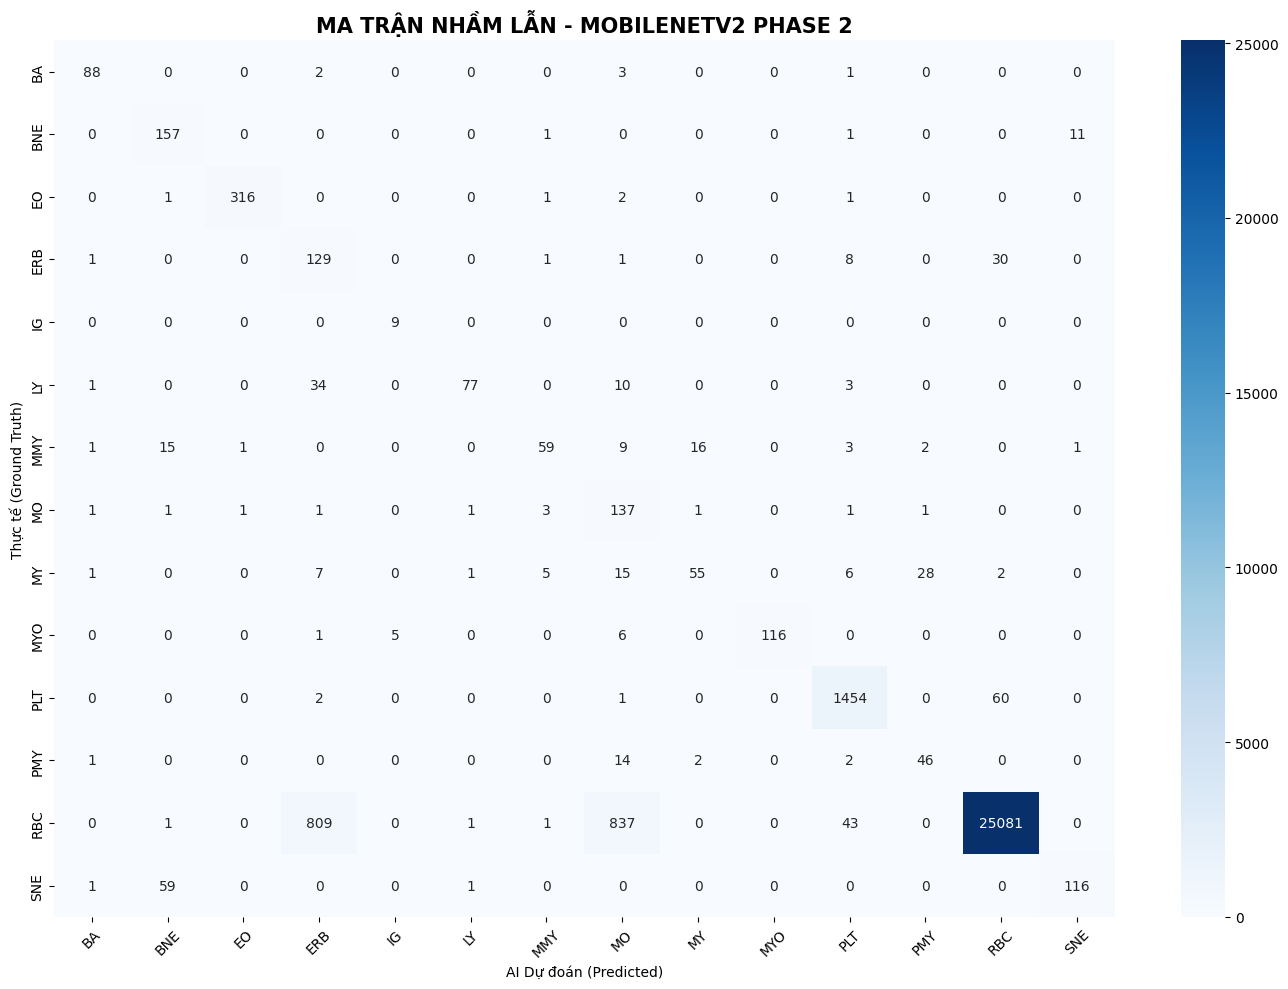


📊 BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

          BA       0.93      0.94      0.93        94
         BNE       0.67      0.92      0.78       170
          EO       0.99      0.98      0.99       321
         ERB       0.13      0.76      0.22       170
          IG       0.64      1.00      0.78         9
          LY       0.95      0.62      0.75       125
         MMY       0.83      0.55      0.66       107
          MO       0.13      0.93      0.23       148
          MY       0.74      0.46      0.57       120
         MYO       1.00      0.91      0.95       128
         PLT       0.95      0.96      0.96      1517
         PMY       0.60      0.71      0.65        65
         RBC       1.00      0.94      0.97     26773
         SNE       0.91      0.66      0.76       177

    accuracy                           0.93     29924
   macro avg       0.75      0.81      0.73     29924
weighted avg       0.98   

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("-" * 60)
print("🚀 CHIẾN DỊCH KIỂM TRA ĐỘC LẬP - MOBILENETV2 PHASE 2")
print("-" * 60)

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN CHUẨN XÁC
# ==========================================
test_dir = '/content/test_keras_cropped'
model_path = '/content/drive/MyDrive/blood_cell_project/models/mobilenetv2_phase2_best.h5'

# ==========================================
# 2. NẠP MÔ HÌNH VÀ DATA
# ==========================================
print(f"[INFO] Đang đánh thức MobileNetV2 từ: {model_path}...")
model = tf.keras.models.load_model(model_path)

test_datagen = ImageDataGenerator(rescale=1./255)

print("[INFO] Đang nạp 29.924 ảnh tế bào vào bệ phóng...")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ==========================================
# 3. AI TIẾN HÀNH DỰ ĐOÁN
# ==========================================
print("\n[INFO] AI đang làm bài test... Vui lòng đợi!")
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# ==========================================
# 4. VẼ MA TRẬN NHẦM LẪN (Đã sửa lỗi đứt gãy)
# ==========================================
print("\n[INFO] Đang kết xuất Ma trận nhầm lẫn...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 10))
# Dòng này đã được nối lại liền mạch để tránh lỗi copy
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.title('MA TRẬN NHẦM LẪN - MOBILENETV2 PHASE 2', fontsize=15, fontweight='bold')
plt.ylabel('Thực tế (Ground Truth)')
plt.xlabel('AI Dự đoán (Predicted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# 5. XUẤT BÁO CÁO TỔNG KẾT
# ==========================================
print("\n" + "="*60)
print("📊 BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT)")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))

final_acc = np.sum(y_pred == y_true) / len(y_true)
print(f"\n🎯 ĐỘ CHÍNH XÁC CUỐI CÙNG (FINAL ACCURACY): {final_acc*100:.2f}%")

------------------------------------------------------------
🛡️ KÍCH HOẠT BỘ LỌC TỰ TIN (CONFIDENCE THRESHOLD TUNING)
------------------------------------------------------------
🧹 Đã dọn dẹp: Trả 859 ca ERB giả mạo và 828 ca MO giả mạo về lại thành RBC.

📊 BÁO CÁO PHÂN LOẠI MỚI (SAU KHI LỌC)
              precision    recall  f1-score   support

          BA       0.93      0.94      0.93        94
         BNE       0.67      0.92      0.78       170
          EO       0.99      0.98      0.99       321
         ERB       0.88      0.65      0.75       170
          IG       0.64      1.00      0.78         9
          LY       0.95      0.62      0.75       125
         MMY       0.83      0.55      0.66       107
          MO       0.56      0.78      0.65       148
          MY       0.74      0.46      0.57       120
         MYO       1.00      0.91      0.95       128
         PLT       0.95      0.96      0.96      1517
         PMY       0.60      0.71      0.65        65
   

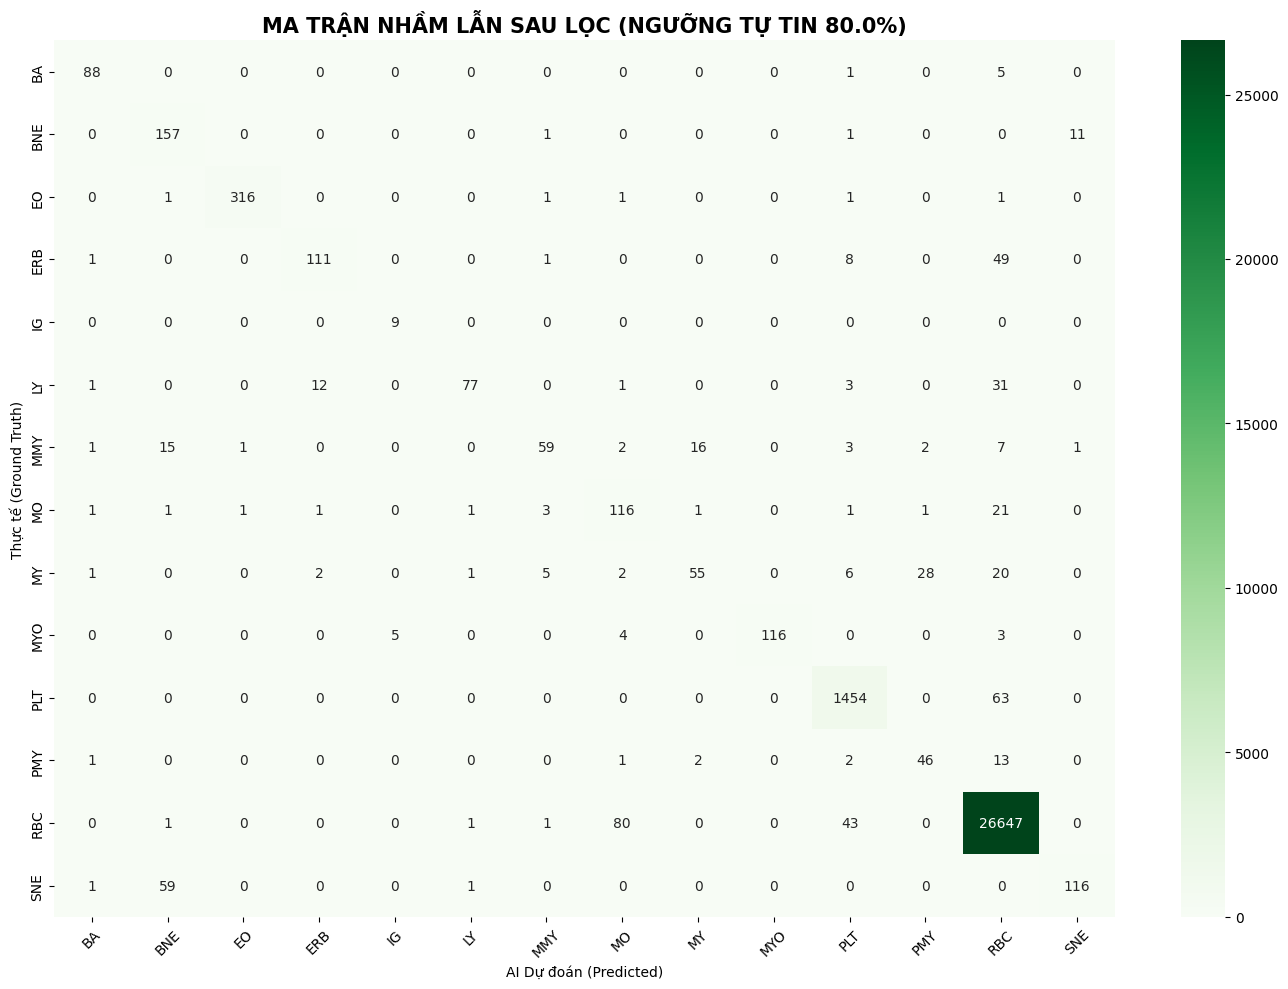

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("-" * 60)
print("🛡️ KÍCH HOẠT BỘ LỌC TỰ TIN (CONFIDENCE THRESHOLD TUNING)")
print("-" * 60)

# ==========================================
# 1. THIẾT LẬP NGƯỠNG VÀ LẤY VỊ TRÍ CLASS
# ==========================================
# Cài đặt ngưỡng tự tin: Dưới 80% là bác bỏ!
CONFIDENCE_THRESHOLD = 0.80

# Tìm chính xác số thứ tự của các lớp tội đồ và nạn nhân
erb_idx = class_names.index('ERB')
mo_idx = class_names.index('MO')
rbc_idx = class_names.index('RBC')

# Lấy lại xác suất dự đoán cao nhất của từng ảnh (Confidence Score)
confidences = np.max(predictions, axis=1)
# Tạo một bản sao của y_pred cũ để chỉnh sửa
y_pred_tuned = np.argmax(predictions, axis=1).copy()

# ==========================================
# 2. TIẾN HÀNH THANH TRỪNG "KẺ MẠO DANH"
# ==========================================
fixed_erb = 0
fixed_mo = 0

for i in range(len(y_pred_tuned)):
    pred_class = y_pred_tuned[i]
    conf = confidences[i]

    # Nếu đoán là ERB nhưng lấp lửng (tự tin < 0.80) -> Đánh tụt về RBC
    if pred_class == erb_idx and conf < CONFIDENCE_THRESHOLD:
        y_pred_tuned[i] = rbc_idx
        fixed_erb += 1

    # Nếu đoán là MO nhưng lấp lửng (tự tin < 0.80) -> Đánh tụt về RBC
    elif pred_class == mo_idx and conf < CONFIDENCE_THRESHOLD:
        y_pred_tuned[i] = rbc_idx
        fixed_mo += 1

print(f"🧹 Đã dọn dẹp: Trả {fixed_erb} ca ERB giả mạo và {fixed_mo} ca MO giả mạo về lại thành RBC.")

# ==========================================
# 3. KẾT XUẤT LẠI BÁO CÁO VÀ MA TRẬN
# ==========================================
print("\n" + "="*60)
print("📊 BÁO CÁO PHÂN LOẠI MỚI (SAU KHI LỌC)")
print("="*60)
print(classification_report(y_true, y_pred_tuned, target_names=class_names))

# Tính lại Accuracy mới
final_acc_tuned = np.sum(y_pred_tuned == y_true) / len(y_true)
print(f"\n🎯 ĐỘ CHÍNH XÁC MỚI (TUNED ACCURACY): {final_acc_tuned*100:.2f}%")

# Vẽ lại Ma trận để kiểm chứng
cm_tuned = confusion_matrix(y_true, y_pred_tuned)
plt.figure(figsize=(14, 10))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', # Đổi sang màu Xanh lá cho phiên bản mới
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'MA TRẬN NHẦM LẪN SAU LỌC (NGƯỠNG TỰ TIN {CONFIDENCE_THRESHOLD*100}%)', fontsize=15, fontweight='bold')
plt.ylabel('Thực tế (Ground Truth)')
plt.xlabel('AI Dự đoán (Predicted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()